LoanForest is a Streamlit web application that predicts the risk of loan default using a Random Forest machine learning model. Users interact with the app via feature sliders to input loan and applicant details, receiving an instant prediction of default risk.

**Loading Necessary Libraries**

In [59]:
# Utilities and data manipulation libraries
import joblib
import pandas as pd
import numpy as np
import logging

# Data visualization libraries
import seaborn as sns
from matplotlib import pyplot as plt

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Model evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib
matplotlib.use("TkAgg")

%matplotlib inline

**Loading Dataset**

In [2]:
# Loading the dataset
df = pd.read_csv("../data/loan_data.csv")

In [3]:
# Displaying the first few rows of the dataset
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


**Data Preview and Cleaning**

In [4]:
# Data Overview and Cleaning Function
def data_preview(df):
    """
    Provides a quick overview of the dataframe including:
      shape, 
      info, 
      description, 
      missing values
      duplicates.
    Parameters:
        df: The input dataframe.
    Returns:
        None
    """
    print("Dataframe Shape:", df.shape)
    print("\nDataframe Info:")
    print(df.info())
    print("\nDataframe Description:")
    print(df.describe())
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nNumber of Duplicates:") 
    print(df.duplicated().sum())
    print("\nCount of Values Not Fully Paid:")
    print(df['not.fully.paid'].value_counts())

# Calling the data preview function
data_preview(df)

Dataframe Shape: (9578, 14)

Dataframe Info:
<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None

Dataframe Description:
    

**Exploratory Data Analysis (EDA)**

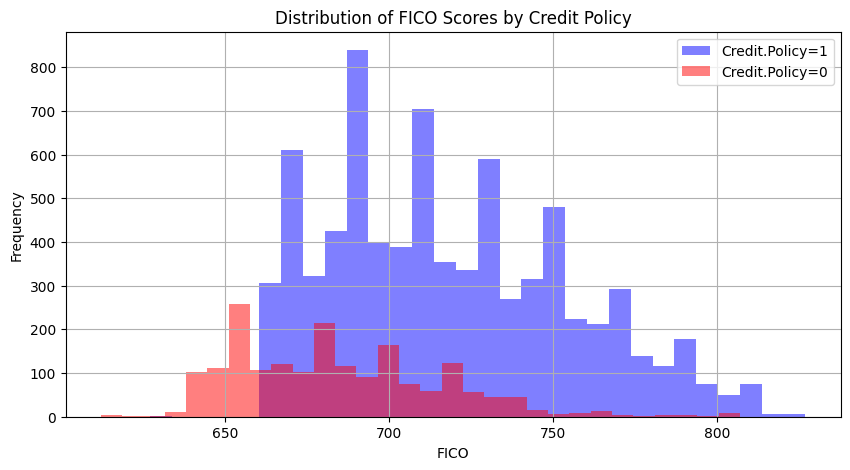

In [12]:
# Histogram of two FICO distributions, for credit.policy=1 and credit.policy=0.
plt.figure(figsize=(10, 5))
df[df['credit.policy']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='Credit.Policy=1')
df[df['credit.policy']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='Credit.Policy=0')
plt.legend()
plt.xlabel('FICO')
plt.ylabel('Frequency')
plt.title('Distribution of FICO Scores by Credit Policy')
plt.show()

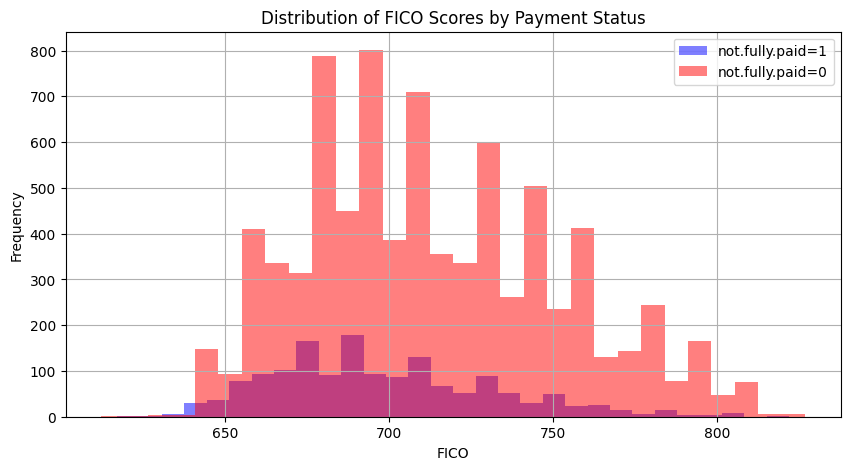

In [13]:
# Histogram of two FICO distributions, for not.fully.paid each 1 & 0.
plt.figure(figsize=(10, 5))
df[df['not.fully.paid']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='not.fully.paid=1')
df[df['not.fully.paid']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='not.fully.paid=0')
plt.legend()
plt.xlabel('FICO')
plt.ylabel('Frequency')
plt.title('Distribution of FICO Scores by Payment Status')
plt.show()

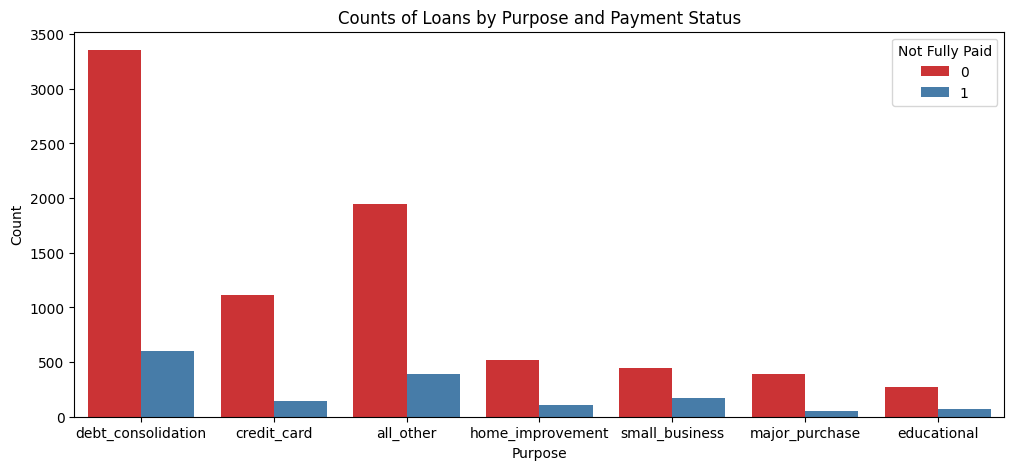

In [11]:
# Countplot showing the counts of loans by purpose, with the color hue defined by not.fully.paid.
plt.figure(figsize=(12, 5))
sns.countplot(x='purpose', hue='not.fully.paid', data=df, palette='Set1')
plt.title('Counts of Loans by Purpose and Payment Status')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.legend(title='Not Fully Paid')
plt.show()

<Figure size 1000x500 with 0 Axes>

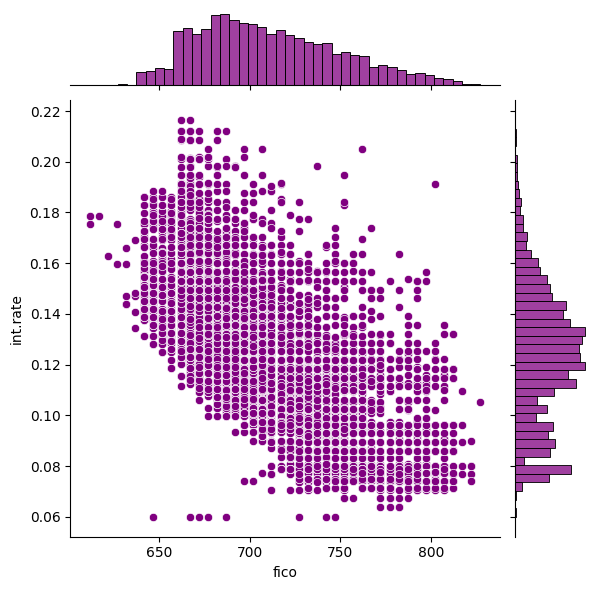

In [15]:
# Plotting the trend between FICO score and interest rate.
plt.figure(figsize=(10, 5))
sns.jointplot(x='fico', y='int.rate', data=df, color='purple')
plt.show()

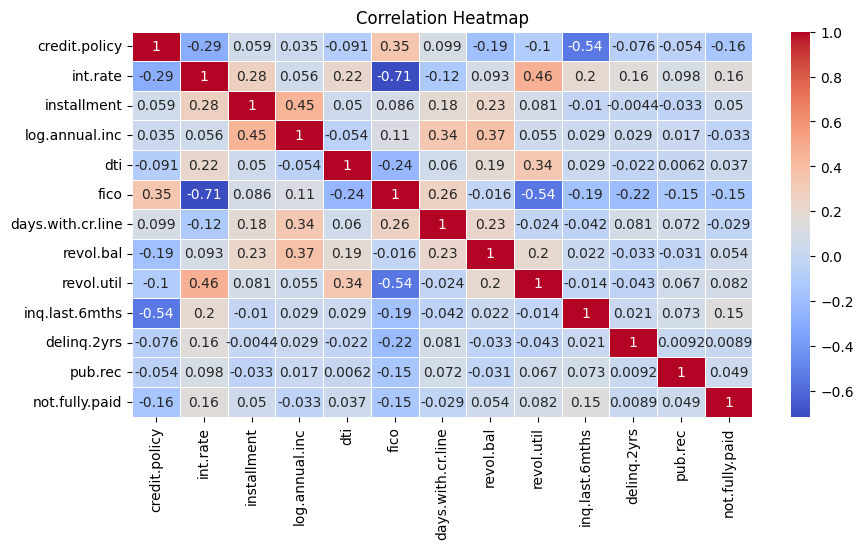

In [16]:
# Computing the correlation matrix and visualizing it with a heatmap.
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Feature Engineering**

In [ ]:
# Function to split data into training and testing sets
def split_data(data):
    """
    This function splits the dataframe into training and testing sets.
    1. Convert categorical variables into numeric using OrdinalEncoder.
    2. Assign the independent variable to X and the dependent variable to y.
    3. Splits the dataset into training and testing sets using an 80-20 ratio.
    4. Normalize the large value using StandardScaler
    
    Args:
        df (pd.DataFrame): The input dataframe to be split.
    Returns:
        X_train, X_test, y_train, y_test: Split datasets.
    """  
    # Convert categorical variables into numeric using OrdinalEncoder
    categorical_cols = data.select_dtypes(include=['str']).columns
    encoder = OrdinalEncoder()
    data[categorical_cols] = encoder.fit_transform(data[categorical_cols])    

    # Assign features variables to X
    X = data.drop(columns='not.fully.paid')
    # Assign target variables to y
    y = data['not.fully.paid']
    
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Fit and transform training data
    sc = StandardScaler()
    X_train_scale = sc.fit_transform(X_train)

    # Transform the testing data
    X_test_scale = sc.transform(X_test)

    # Print the shapes of the split datasets
    print("X_train shape: {}".format(X_train.shape))
    print("X_test shape: {}".format(X_test.shape))
    print("y_train shape: {}".format(y_train.shape))
    print("y_test shape: {}".format(y_test.shape))
    
    return X_train_scale, X_test_scale, y_train, y_test

In [51]:
# Apply the split_data function to the preprocessed dataframe
X_train_scale, X_test_scale, y_train, y_test = split_data(df)

X_train shape: (7662, 13)
X_test shape: (1916, 13)
y_train shape: (7662,)
y_test shape: (1916,)


**Model Development.**

In [58]:
# Training Data using randomforestclassifier
rf = RandomForestClassifier(random_state=42)
# Fit and train
rf.fit(X_train_scale, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [60]:
# Predicting the test set results
y_pred = rf.predict(X_test_scale)

In [61]:
# Function to display classification report and confusion matrix
def model_result(y_true, y_hat):
    """
    Displays the confusion matrix and classification report for the given true and predicted labels.
    Args:
        y_true: The true labels.
        y_hat: The predicted labels.
    Return:
        
    """
    # Compute the confusion matrix.
    cm = confusion_matrix(y_test, y_pred)

    # Visualize using heatmap.
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, cmap='coolwarm', linewidths=0.5,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    
    plt.title('Confusion Matrix')
    plt.ylabel("Actual Labels.")
    plt.xlabel("Predicted Labels.")
    plt.show()

    # Display the classification report.
    cr = classification_report(y_test, y_pred)
    print(cr)

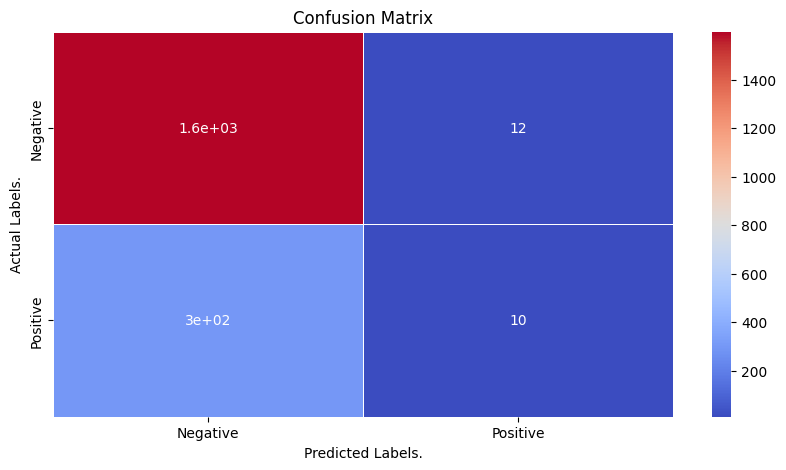

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1609
           1       0.45      0.03      0.06       307

    accuracy                           0.84      1916
   macro avg       0.65      0.51      0.49      1916
weighted avg       0.78      0.84      0.78      1916



In [ ]:
# Initialize the model evaluation function
model_result(y_test, y_pred)

In [ ]:
# Save the trained model to disk
filename = 'finalized_logistic_model.pkl'

# Save the trained model to disk
joblib.dump(rf, filename)

print("Model successfully saved to {}".format(filename))

In [ ]:
# Function to load the model make predictions.
def load_and_predict(data):
    """
    Loads a trained model makes predictions on new data and inverse the transform label.
        1. Loads the trained model from disk.
        2. Makes predictions on the provided clean dataframe.
    Args:
        clean_df (pd.DataFrame): The preprocessed test dataframe.
    Returns:
        np.ndarray: The predicted labels in their original categorical form.
    """
    try:
        print("Loading the trained model...")
        # Load the trained model
        model = joblib.load('finalized_logistic_model.pkl')
        print("Model loaded successfully.")
        # Make predictions
        predictions = model.predict(data)
        print("Predictions made successfully.")

    except FileNotFoundError:
        logging.error("Error: The model file was not found. Please ensure the model has been trained and saved correctly.")
        return None
    except KeyError as e:
        logging.error("Prediction Error. Feature mismatch likely. {}".format(e))
        return None
    except Exception as e:  
        logging.error("An error occurred while loading the model: {}".format(e))
        return None

    return predictions